# 🛠️ Mineração de Dados 
## Módulo 2: Pré-processamento de Dados

---

## 🎯 Objetivos deste Notebook

Ao concluir este notebook, você será capaz de:

1. ✅ Diagnosticar problemas de qualidade em dados reais
2. ✅ Visualizar e comparar estratégias de imputação de valores ausentes
3. ✅ Detectar outliers com 4 métodos diferentes (Z-score, IQR, Isolation Forest, LOF)
4. ✅ Aplicar e comparar normalizadores (StandardScaler, MinMaxScaler, RobustScaler)
5. ✅ Selecionar atributos com métodos de filtro, wrapper e embutidos
6. ✅ Realizar redução de dimensionalidade com PCA
7. ✅ Balancear classes desbalanceadas com SMOTE e ADASYN
8. ✅ Construir um pipeline completo de pré-processamento com sklearn

---

## 📋 Sumário

1. [Setup](#setup)
2. [Carregando Dataset com Problemas Reais](#dataset)
3. [Visualizando Dados Ausentes](#missing_viz)
4. [Estratégias de Imputação Comparadas](#imputation)
5. [Detecção de Outliers](#outliers)
6. [Normalização e Escalonamento](#scaling)
7. [Seleção de Atributos](#feature_selection)
8. [Redução de Dimensionalidade — PCA](#pca)
9. [Balanceamento de Classes — SMOTE](#smote)
10. [Pipeline Completo de Pré-processamento](#pipeline)
11. [Exercícios](#exercicios)


In [1]:
# Instalar dependências necessárias (execute apenas uma vez)
!pip install -q imbalanced-learn missingno scikit-learn pandas numpy matplotlib seaborn scipy plotly
print('Instalação concluída!')

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## 📦 Setup <a id='setup'></a>


In [12]:
# ============================================================
# IMPORTAÇÕES COMPLETAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.stats as stats
import warnings

# Visualização de dados ausentes
try:
    import missingno as msno
    MISSINGNO_AVAILABLE = True
except ImportError:
    MISSINGNO_AVAILABLE = False
    print('missingno não disponível, usando alternativa.')

# Pré-processamento
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    MaxAbsScaler, PowerTransformer, LabelEncoder, OneHotEncoder
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # Habilitar IterativeImputer
from sklearn.impute import IterativeImputer

# Detecção de outliers
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Seleção de features
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif,
    RFE, SelectFromModel
)
from sklearn.linear_model import LogisticRegression, Lasso

# Redução de dimensionalidade
from sklearn.decomposition import PCA

# Modelos e avaliação
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

# Balanceamento de classes
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Configurações globais
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
matplotlib.rcParams['figure.figsize'] = (13, 6)
matplotlib.rcParams['font.size'] = 11
sns.set_palette('husl')

import sklearn
import imblearn
print('=' * 55)
print('VERSÕES DAS BIBLIOTECAS')
print('=' * 55)
print(f'NumPy:           {np.__version__}')
print(f'Pandas:          {pd.__version__}')
print(f'Scikit-learn:    {sklearn.__version__}')
print(f'Imbalanced-learn:{imblearn.__version__}')
print(f'Matplotlib:      {matplotlib.__version__}')
print('=' * 55)
print('Ambiente configurado!')

VERSÕES DAS BIBLIOTECAS
NumPy:           1.26.4
Pandas:          2.3.3
Scikit-learn:    1.9.0
Imbalanced-learn:0.14.2
Matplotlib:      3.10.0
Ambiente configurado!


## 🔴 1. Carregando um Dataset com Problemas Reais <a id='dataset'></a>

Criamos um dataset sintético **propositalmente problemático** que simula
dados do mundo real: valores ausentes, outliers, features correlacionadas e
desbalanceamento de classes.


In [13]:
# ============================================================
# CRIAR DATASET SINTÉTICO COM PROBLEMAS REAIS
# ============================================================

def create_messy_dataset(n_samples=800, random_state=42):
    """Cria um dataset com problemas comuns em dados reais."""
    rng = np.random.RandomState(random_state)

    # Gerar dados base (classificação binária)
    X_clean, y = make_classification(
        n_samples=n_samples,
        n_features=8,
        n_informative=5,
        n_redundant=2,
        n_repeated=0,
        n_classes=2,
        weights=[0.85, 0.15],   # Desbalanceado: 85% classe 0, 15% classe 1
        random_state=random_state
    )

    # Criar DataFrame com nomes descritivos
    df = pd.DataFrame(X_clean, columns=[
        'idade', 'renda', 'historico_credito',
        'num_emprestimos', 'tempo_emprego',
        'saldo_conta', 'score_anterior', 'num_dependentes'
    ])
    df['inadimplente'] = y  # 1 = inadimplente, 0 = adimplente

    # --- Introduzir valores ausentes (MAR e MCAR) ---
    # MCAR: falha aleatória no sistema (campo renda)
    mcar_idx = rng.choice(n_samples, size=int(0.12 * n_samples), replace=False)
    df.loc[mcar_idx, 'renda'] = np.nan

    # MAR: clientes inadimplentes tendem a não informar historico
    mar_idx = df[df['inadimplente'] == 1].sample(
        frac=0.40, random_state=random_state
    ).index
    df.loc[mar_idx, 'historico_credito'] = np.nan

    # MCAR aleatório em outras colunas
    for col in ['tempo_emprego', 'num_dependentes']:
        idx = rng.choice(n_samples, size=int(0.07 * n_samples), replace=False)
        df.loc[idx, col] = np.nan

    # --- Introduzir outliers extremos ---
    outlier_idx = rng.choice(n_samples, size=15, replace=False)
    df.loc[outlier_idx[:8],  'renda']        = df['renda'].mean() * rng.uniform(8, 15, 8)
    df.loc[outlier_idx[8:12], 'saldo_conta'] = df['saldo_conta'].min() - abs(df['saldo_conta'].std()) * 5
    df.loc[outlier_idx[12:],  'idade']       = df['idade'].mean() + df['idade'].std() * rng.uniform(4, 6, 3)

    # --- Introduzir duplicatas ---
    dup_rows = df.sample(10, random_state=random_state)
    df = pd.concat([df, dup_rows], ignore_index=True)

    return df

# Criar o dataset
df_raw = create_messy_dataset(n_samples=800, random_state=42)

print('DATASET CRIADO COM SUCESSO!')
print('=' * 55)
print(f'Dimensões: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas')
print(f'Colunas:   {list(df_raw.columns)}')
print()
print('Primeiras 8 linhas:')
display(df_raw.head(8))

DATASET CRIADO COM SUCESSO!
Dimensões: 810 linhas x 9 colunas
Colunas:   ['idade', 'renda', 'historico_credito', 'num_emprestimos', 'tempo_emprego', 'saldo_conta', 'score_anterior', 'num_dependentes', 'inadimplente']

Primeiras 8 linhas:


,idade,renda,historico_credito,num_emprestimos,tempo_emprego,saldo_conta,score_anterior,num_dependentes,inadimplente
0,0.651696,1.439699,-0.979108,0.394261,1.577692,-1.568649,-0.991290,-1.496982,0
1,0.682056,-0.022335,-0.850218,1.829454,1.915087,-1.160085,1.950852,-1.461774,0
2,0.906387,-0.865566,-2.908109,-0.733694,2.190319,-2.203230,0.415551,0.829645,0
3,-1.810772,-1.022550,-0.837617,2.476119,-0.182204,3.259890,-2.573524,-0.727678,0
4,1.517563,-0.641107,-0.930578,2.766761,1.166651,-0.729276,-0.491738,-1.105445,0
5,2.457385,0.929114,NaN,1.375756,-2.463081,1.454278,0.390941,0.606016,1
6,-2.331683,-1.771171,-1.509373,2.622994,1.711217,2.353703,0.198676,-1.020479,0
7,2.243408,2.313658,-0.913368,-0.685205,1.010358,-3.063914,1.319636,-1.011675,0


In [14]:
# ============================================================
# RELATÓRIO DE DIAGNÓSTICO DOS DADOS
# ============================================================

print('RELATÓRIO DE DIAGNÓSTICO DE QUALIDADE DOS DADOS')
print('=' * 60)

# 1. Valores ausentes
print('\n[1] VALORES AUSENTES POR COLUNA')
print('-' * 45)
missing_info = pd.DataFrame({
    'Ausentes': df_raw.isnull().sum(),
    'Percentual (%)': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
missing_info = missing_info[missing_info['Ausentes'] > 0].sort_values('Ausentes', ascending=False)
print(missing_info.to_string())

# 2. Tipos de dados
print('\n[2] TIPOS DE DADOS')
print('-' * 45)
print(df_raw.dtypes)

# 3. Valores únicos por coluna
print('\n[3] VALORES ÚNICOS POR COLUNA')
print('-' * 45)
for col in df_raw.columns:
    n_unique = df_raw[col].nunique()
    print(f'  {col:25s}: {n_unique} valores únicos')

# 4. Linhas duplicadas
print('\n[4] LINHAS DUPLICADAS')
print('-' * 45)
n_dup = df_raw.duplicated().sum()
print(f'  Total de linhas duplicadas: {n_dup} ({n_dup/len(df_raw)*100:.1f}%)')

# 5. Distribuição do target
print('\n[5] DISTRIBUIÇÃO DO TARGET (inadimplente)')
print('-' * 45)
target_dist = df_raw['inadimplente'].value_counts()
for val, count in target_dist.items():
    label = 'Inadimplente' if val == 1 else 'Adimplente'
    print(f'  {label} ({val}): {count} ({count/len(df_raw)*100:.1f}%)')
print()
print('Diagnóstico concluído!')

RELATÓRIO DE DIAGNÓSTICO DE QUALIDADE DOS DADOS

[1] VALORES AUSENTES POR COLUNA
---------------------------------------------
                   Ausentes  Percentual (%)
renda                   103           12.72
tempo_emprego            56            6.91
num_dependentes          56            6.91
historico_credito        50            6.17

[2] TIPOS DE DADOS
---------------------------------------------
idade                float64
renda                float64
historico_credito    float64
num_emprestimos      float64
tempo_emprego        float64
saldo_conta          float64
score_anterior       float64
num_dependentes      float64
inadimplente           int64
dtype: object

[3] VALORES ÚNICOS POR COLUNA
---------------------------------------------
  idade                    : 800 valores únicos
  renda                    : 706 valores únicos
  historico_credito        : 750 valores únicos
  num_emprestimos          : 800 valores únicos
  tempo_emprego            : 744 valores ún

## 🔍 2. Visualizando Dados Ausentes <a id='missing_viz'></a>

Usamos a biblioteca `missingno` para visualizar padrões de ausência.
Isso ajuda a diagnosticar o mecanismo de ausência (MCAR, MAR, MNAR).


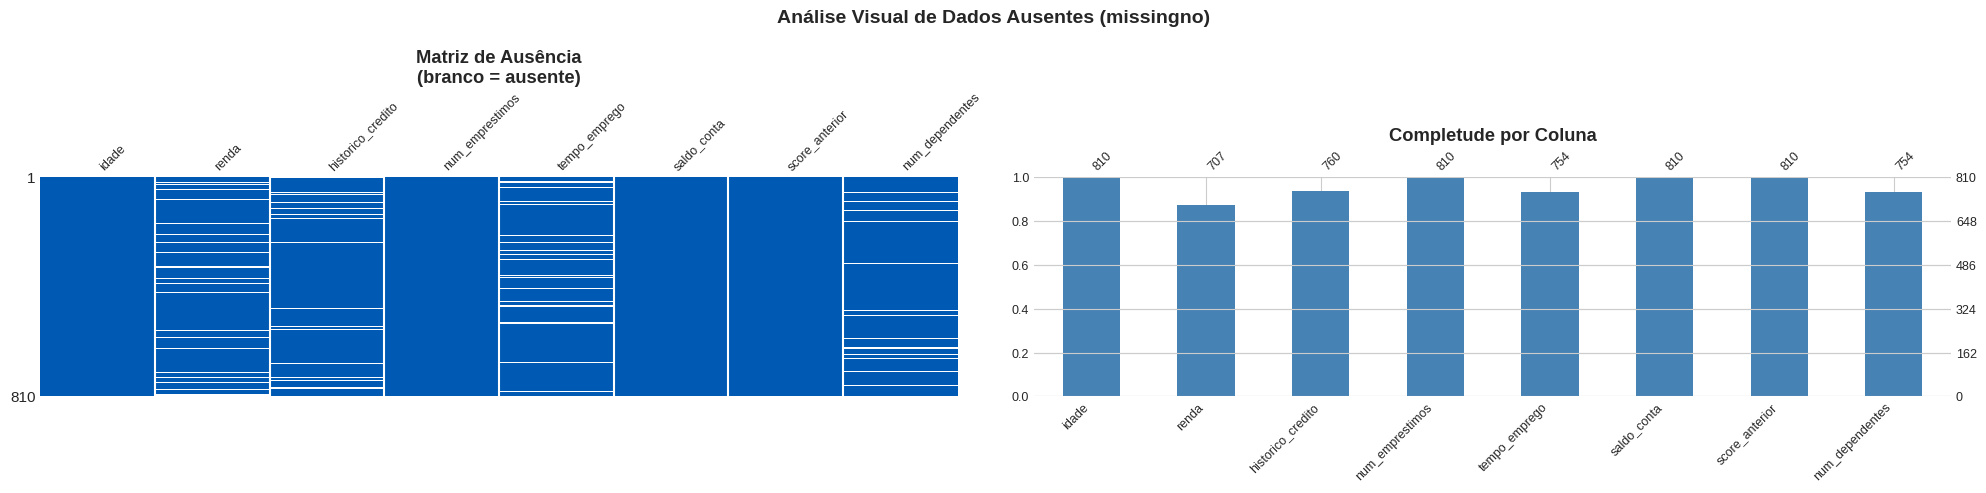


DIAGNÓSTICO DO PADRÃO DE AUSÊNCIA
--------------------------------------------------
  renda:              MCAR (falha aleatória do sistema)
  historico_credito:  MAR  (ausente mais em inadimplentes)
  tempo_emprego:      MCAR (ausente aleatoriamente)
  num_dependentes:    MCAR (ausente aleatoriamente)


In [17]:
# ============================================================
# VISUALIZAÇÃO DE DADOS AUSENTES
# ============================================================

# Colunas numéricas apenas (sem o target)
feature_cols = [c for c in df_raw.columns if c != 'inadimplente']
df_features = df_raw[feature_cols]

if MISSINGNO_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(20, 5))
    fig.suptitle('Análise Visual de Dados Ausentes (missingno)', fontsize=14, fontweight='bold')

    # Matrix: padrão de ausência linha a linha
    msno.matrix(df_features, ax=axes[0], sparkline=False, fontsize=9, color=(0.0, 0.35, 0.7))
    axes[0].set_title('Matriz de Ausência\n(branco = ausente)', fontweight='bold')

    # Bar: quantidade de ausentes por coluna
    msno.bar(df_features, ax=axes[1], fontsize=9, color='steelblue')
    axes[1].set_title('Completude por Coluna', fontweight='bold')

  
    plt.tight_layout()
    plt.show()
else:
    # Alternativa sem missingno: heatmap manual
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Mapa de calor de ausências
    missing_matrix = df_features.isnull().astype(int)
    sns.heatmap(missing_matrix.T, cmap='Blues', ax=axes[0],
                cbar=False, yticklabels=True)
    axes[0].set_title('Matriz de Ausência\n(azul = ausente)', fontweight='bold')
    axes[0].set_xlabel('Amostras')

    # Barras de completude
    completude = (1 - df_features.isnull().mean()) * 100
    axes[1].barh(completude.index, completude.values, color='steelblue', edgecolor='navy')
    axes[1].set_xlabel('Completude (%)')
    axes[1].set_title('Completude por Coluna', fontweight='bold')
    axes[1].axvline(x=95, color='red', linestyle='--', alpha=0.7, label='Limite 95%')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Diagnóstico textual
print('\nDIAGNÓSTICO DO PADRÃO DE AUSÊNCIA')
print('-' * 50)
print('  renda:              MCAR (falha aleatória do sistema)')
print('  historico_credito:  MAR  (ausente mais em inadimplentes)')
print('  tempo_emprego:      MCAR (ausente aleatoriamente)')
print('  num_dependentes:    MCAR (ausente aleatoriamente)')

## 🛠️ 3. Estratégias de Imputação Comparadas <a id='imputation'></a>

Comparamos 5 estratégias de imputação avaliando o impacto na performance de um classificador.


Comparando estratégias de imputação...
Estratégia                | Acurácia   | F1-Score  
----------------------------------------------------
Média                     | 0.9187±0.016 | 0.7200±0.068
Mediana                   | 0.9100±0.015 | 0.7041±0.051
Moda                      | 0.9287±0.014 | 0.7597±0.039
KNN (k=5)                 | 0.9025±0.013 | 0.6545±0.058
Iterativo (MICE)          | 0.9037±0.021 | 0.6642±0.090


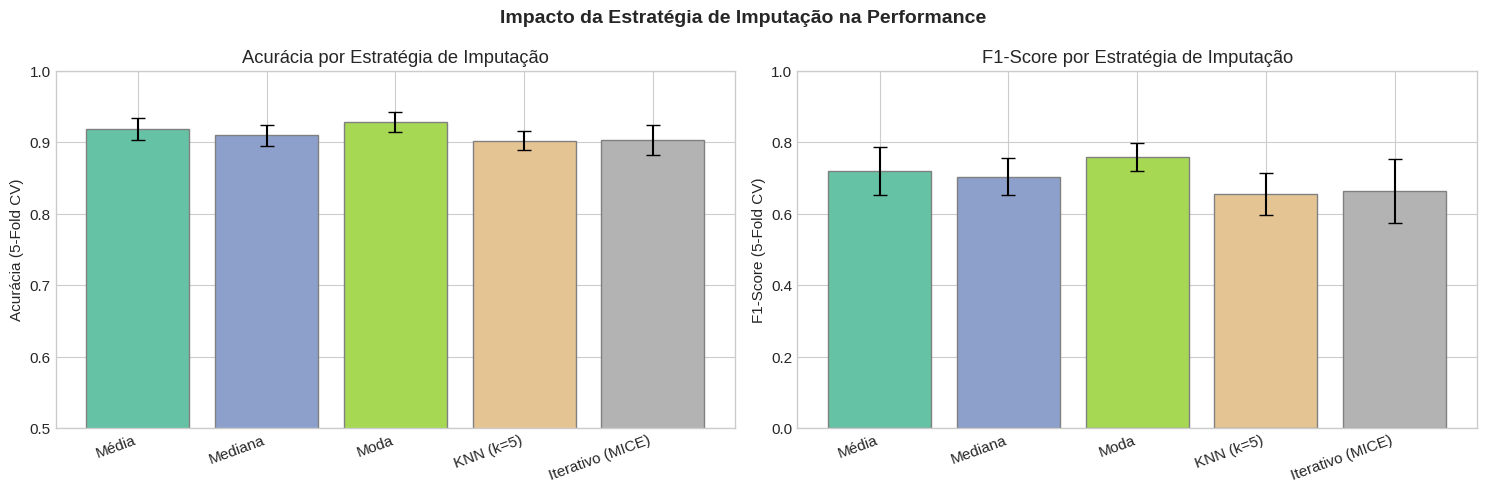

In [18]:
# ============================================================
# COMPARAÇÃO DE 5 ESTRATÉGIAS DE IMPUTAÇÃO
# ============================================================

# Remover duplicatas primeiro
df_clean = df_raw.drop_duplicates().reset_index(drop=True)

X_raw = df_clean[feature_cols].values
y_all = df_clean['inadimplente'].values

# Definir as estratégias de imputação
imputers = {
    'Média':             SimpleImputer(strategy='mean'),
    'Mediana':           SimpleImputer(strategy='median'),
    'Moda':              SimpleImputer(strategy='most_frequent'),
    'KNN (k=5)':         KNNImputer(n_neighbors=5),
    'Iterativo (MICE)':  IterativeImputer(max_iter=10, random_state=42)
}

# Classificador base para avaliação
base_clf = RandomForestClassifier(n_estimators=80, random_state=42, class_weight='balanced')
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Comparando estratégias de imputação...')
print(f'{"Estratégia":25s} | {"Acurácia":10s} | {"F1-Score":10s}')
print('-' * 52)

imputation_results = {}
for name, imputer in imputers.items():
    # Pipeline: imputer + scaler + classifier
    pipe = Pipeline([
        ('imputer', imputer),
        ('scaler',  StandardScaler()),
        ('clf',     base_clf)
    ])
    acc_scores = cross_val_score(pipe, X_raw, y_all, cv=cv5, scoring='accuracy', n_jobs=-1)
    f1_scores  = cross_val_score(pipe, X_raw, y_all, cv=cv5, scoring='f1',       n_jobs=-1)
    imputation_results[name] = {
        'acc_mean': acc_scores.mean(),
        'acc_std':  acc_scores.std(),
        'f1_mean':  f1_scores.mean(),
        'f1_std':   f1_scores.std()
    }
    print(f'{name:25s} | {acc_scores.mean():.4f}±{acc_scores.std():.3f} | {f1_scores.mean():.4f}±{f1_scores.std():.3f}')

# --- Gráfico comparativo ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Impacto da Estratégia de Imputação na Performance', fontsize=14, fontweight='bold')

names_imp = list(imputation_results.keys())
acc_means = [imputation_results[n]['acc_mean'] for n in names_imp]
acc_stds  = [imputation_results[n]['acc_std']  for n in names_imp]
f1_means  = [imputation_results[n]['f1_mean']  for n in names_imp]
f1_stds   = [imputation_results[n]['f1_std']   for n in names_imp]

x_pos = np.arange(len(names_imp))
colors_imp = plt.cm.Set2(np.linspace(0, 1, len(names_imp)))

ax1.bar(x_pos, acc_means, yerr=acc_stds, capsize=5, color=colors_imp, edgecolor='gray')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(names_imp, rotation=20, ha='right')
ax1.set_ylabel('Acurácia (5-Fold CV)')
ax1.set_title('Acurácia por Estratégia de Imputação')
ax1.set_ylim(0.5, 1.0)

ax2.bar(x_pos, f1_means, yerr=f1_stds, capsize=5, color=colors_imp, edgecolor='gray')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(names_imp, rotation=20, ha='right')
ax2.set_ylabel('F1-Score (5-Fold CV)')
ax2.set_title('F1-Score por Estratégia de Imputação')
ax2.set_ylim(0.0, 1.0)

plt.tight_layout()
plt.show()

## ⚡ 4. Detecção de Outliers <a id='outliers'></a>

Aplicamos 4 métodos de detecção de outliers e comparamos seus resultados.


RESUMO: OUTLIERS DETECTADOS POR MÉTODO
  Z-Score             :   34 outliers (4.2%)
  IQR                 :  135 outliers (16.9%)
  Isolation Forest    :   40 outliers (5.0%)
  LOF                 :   40 outliers (5.0%)


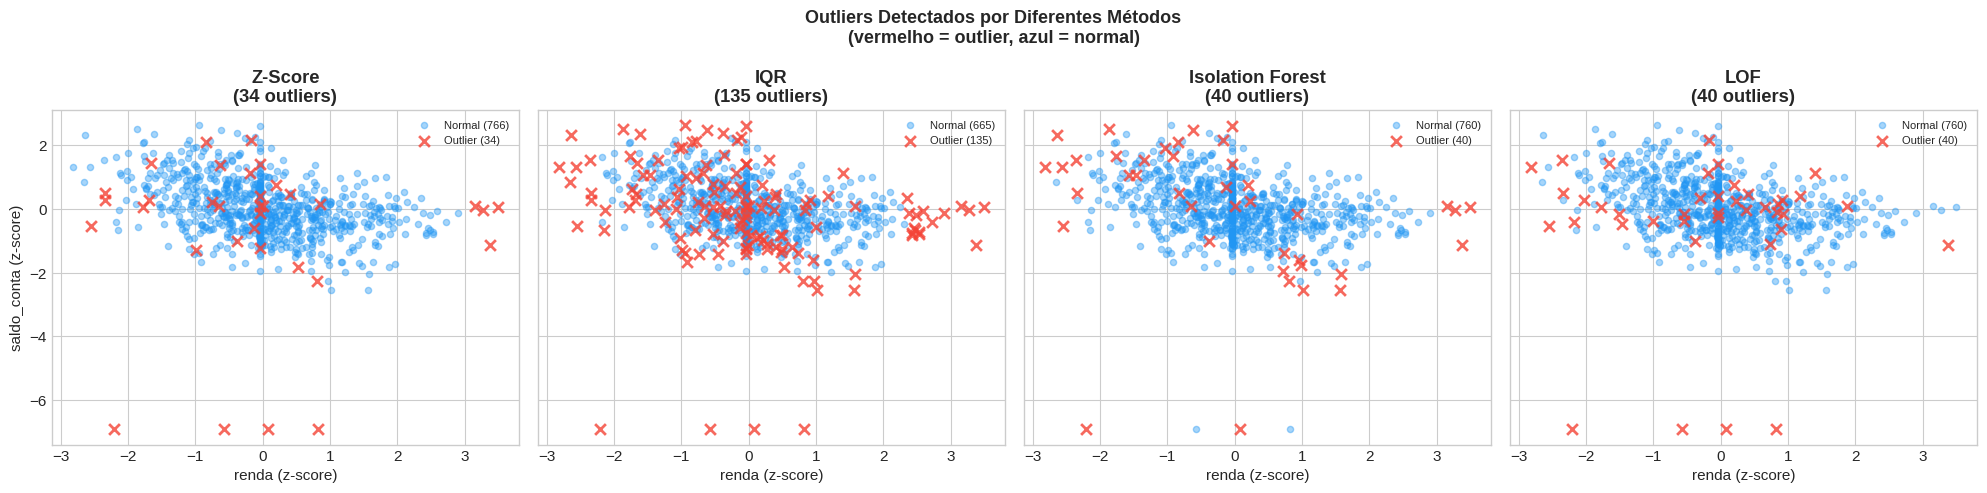

In [19]:
# ============================================================
# DETECÇÃO DE OUTLIERS — 4 MÉTODOS
# ============================================================

# Usar apenas as 2 features mais informativas para visualização 2D
# Primeiro imputar para poder usar algoritmos que não aceitam NaN
imputer_base = SimpleImputer(strategy='median')
X_imputed = imputer_base.fit_transform(df_clean[feature_cols])
X_imputed_df = pd.DataFrame(X_imputed, columns=feature_cols)

# Normalizar para comparação justa
X_scaled_out = StandardScaler().fit_transform(X_imputed)

# Selecionar features renda e saldo_conta para visualização
feat_a, feat_b = 'renda', 'saldo_conta'
idx_a = feature_cols.index(feat_a)
idx_b = feature_cols.index(feat_b)

# --- Método 1: Z-Score ---
z_scores = np.abs(stats.zscore(X_scaled_out, nan_policy='omit'))
zscore_outliers = (z_scores > 3).any(axis=1)  # Outlier se alguma feature tem |z|>3

# --- Método 2: IQR ---
def iqr_outlier_mask(X):
    """Retorna máscara booleana de outliers pelo método IQR."""
    Q1  = np.percentile(X, 25, axis=0)
    Q3  = np.percentile(X, 75, axis=0)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((X < lower) | (X > upper)).any(axis=1)

iqr_outliers = iqr_outlier_mask(X_imputed)

# --- Método 3: Isolation Forest ---
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,   # Espera-se ~5% de outliers
    random_state=42
)
iso_pred = iso_forest.fit_predict(X_scaled_out)
iso_outliers = iso_pred == -1   # -1 = outlier, 1 = inlier

# --- Método 4: LOF (Local Outlier Factor) ---
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)
lof_pred = lof.fit_predict(X_scaled_out)
lof_outliers = lof_pred == -1

# Resumo
print('RESUMO: OUTLIERS DETECTADOS POR MÉTODO')
print('=' * 50)
methods = {'Z-Score': zscore_outliers, 'IQR': iqr_outliers,
           'Isolation Forest': iso_outliers, 'LOF': lof_outliers}
for name, mask in methods.items():
    n_out = mask.sum()
    pct   = n_out / len(mask) * 100
    print(f'  {name:20s}: {n_out:4d} outliers ({pct:.1f}%)')

# --- Visualização comparativa ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Outliers Detectados por Diferentes Métodos\n(vermelho = outlier, azul = normal)',
             fontsize=13, fontweight='bold')

x_2d = X_scaled_out[:, idx_a]   # feature renda (normalizada)
y_2d = X_scaled_out[:, idx_b]   # feature saldo_conta (normalizada)

for ax, (name, mask) in zip(axes, methods.items()):
    # Pontos normais
    ax.scatter(x_2d[~mask], y_2d[~mask], c='#2196F3', alpha=0.4,
               s=20, label=f'Normal ({(~mask).sum()})')
    # Outliers
    ax.scatter(x_2d[mask], y_2d[mask], c='#F44336', alpha=0.8,
               s=60, marker='x', linewidths=2, label=f'Outlier ({mask.sum()})')
    ax.set_title(f'{name}\n({mask.sum()} outliers)', fontweight='bold')
    ax.set_xlabel(f'{feat_a} (z-score)')
    ax.legend(fontsize=8)

axes[0].set_ylabel(f'{feat_b} (z-score)')
plt.tight_layout()
plt.show()

COMPARAÇÃO: TRATAMENTO DE OUTLIERS vs. PERFORMANCE
Manter Outliers           | n= 800 | Acc=0.9087 | F1=0.6920
Remover Outliers          | n= 760 | Acc=0.9171 | F1=0.6994
Winsorizar                | n= 800 | Acc=0.9100 | F1=0.6969


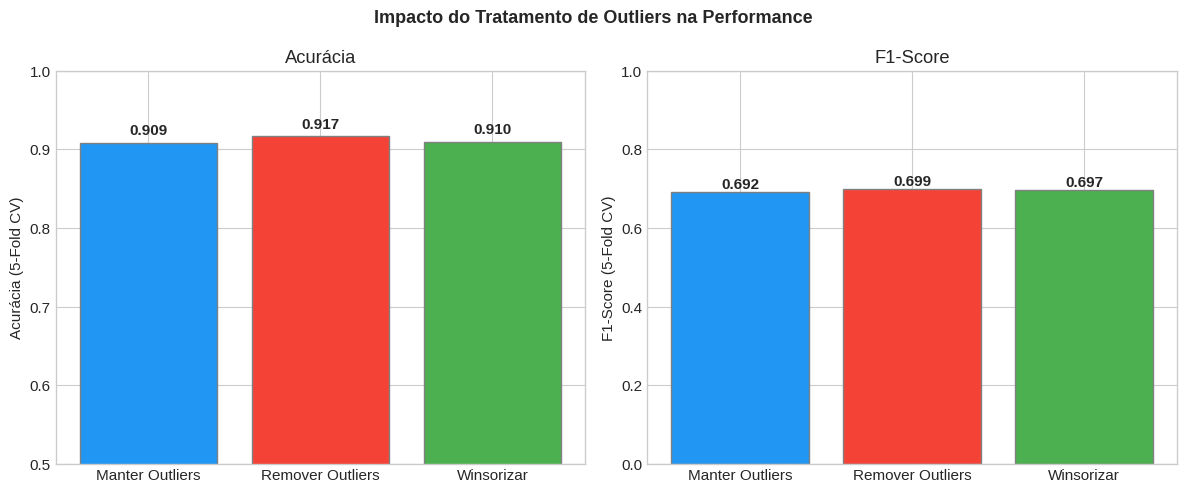

In [20]:
# ============================================================
# COMPARAR ESTRATÉGIAS DE TRATAMENTO DE OUTLIERS
# ============================================================

# Usar Isolation Forest como detector
outlier_mask = iso_outliers
X_no_nan = X_imputed  # Já imputado

def winsorize_array(X, limits=(0.05, 0.05)):
    """Winsorização: substituir extremos pelos percentis limítrofes."""
    X_w = X.copy()
    for j in range(X.shape[1]):
        lo = np.percentile(X[:, j], limits[0] * 100)
        hi = np.percentile(X[:, j], (1 - limits[1]) * 100)
        X_w[:, j] = np.clip(X[:, j], lo, hi)
    return X_w

strategies = {
    'Manter Outliers':   X_no_nan,
    'Remover Outliers':  X_no_nan[~outlier_mask],
    'Winsorizar':        winsorize_array(X_no_nan)
}
y_strategies = {
    'Manter Outliers':   y_all,
    'Remover Outliers':  y_all[~outlier_mask],
    'Winsorizar':        y_all
}

print('COMPARAÇÃO: TRATAMENTO DE OUTLIERS vs. PERFORMANCE')
print('=' * 60)

outlier_results = {}
clf_out = RandomForestClassifier(n_estimators=80, random_state=42, class_weight='balanced')

for name, X_strat in strategies.items():
    y_strat = y_strategies[name]
    pipe_out = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    clf_out)
    ])
    cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    acc = cross_val_score(pipe_out, X_strat, y_strat, cv=cv_strat, scoring='accuracy')
    f1  = cross_val_score(pipe_out, X_strat, y_strat, cv=cv_strat, scoring='f1')
    outlier_results[name] = {
        'n_amostras': len(X_strat),
        'acc': acc.mean(), 'f1': f1.mean()
    }
    print(f'{name:25s} | n={len(X_strat):4d} | Acc={acc.mean():.4f} | F1={f1.mean():.4f}')

# Gráfico comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Impacto do Tratamento de Outliers na Performance', fontsize=13, fontweight='bold')

names_out = list(outlier_results.keys())
colors_out = ['#2196F3', '#F44336', '#4CAF50']

accs = [outlier_results[n]['acc'] for n in names_out]
f1s  = [outlier_results[n]['f1']  for n in names_out]

ax1.bar(names_out, accs, color=colors_out, edgecolor='gray')
ax1.set_ylabel('Acurácia (5-Fold CV)')
ax1.set_title('Acurácia')
ax1.set_ylim(0.5, 1.0)
for i, v in enumerate(accs):
    ax1.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

ax2.bar(names_out, f1s, color=colors_out, edgecolor='gray')
ax2.set_ylabel('F1-Score (5-Fold CV)')
ax2.set_title('F1-Score')
ax2.set_ylim(0.0, 1.0)
for i, v in enumerate(f1s):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## ⚖️ 5. Normalização e Escalonamento <a id='scaling'></a>

Comparamos 5 métodos de escalonamento visualizando as distribuições resultantes.


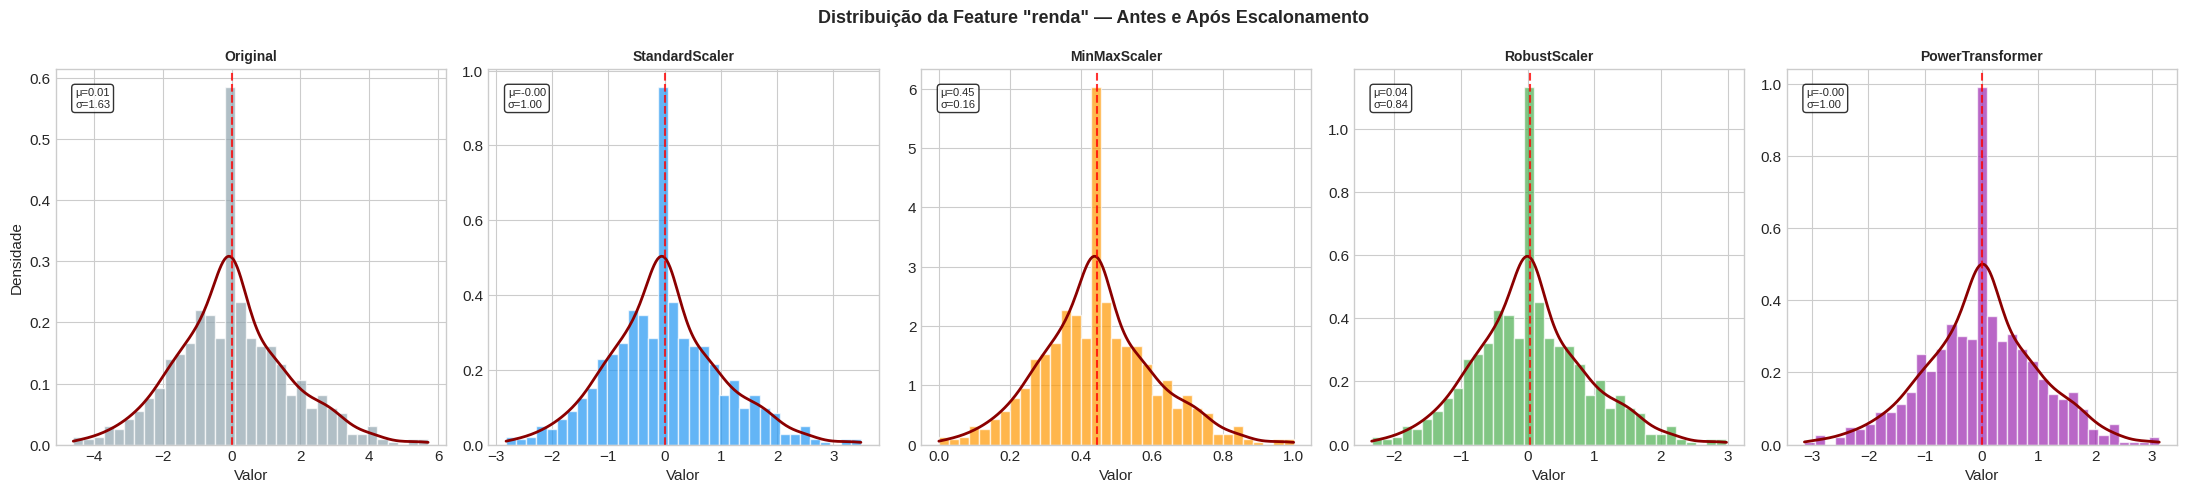


ESTATÍSTICAS COMPARATIVAS POR ESCALADOR
Escalador            | Mín      | Máx      | Média    | DP      
--------------------------------------------------------------
Original             |   -4.595 |    5.706 |    0.006 |    1.633
StandardScaler       |   -2.817 |    3.490 |   -0.000 |    1.000
MinMaxScaler         |    0.000 |    1.000 |    0.447 |    0.159
RobustScaler         |   -2.341 |    2.984 |    0.037 |    0.844
PowerTransformer     |   -3.130 |    3.134 |   -0.000 |    1.000


In [21]:
# ============================================================
# COMPARAÇÃO DE 5 MÉTODOS DE ESCALONAMENTO
# ============================================================

# Usar dataset imputado (sem NaN)
X_for_scale = X_imputed.copy()

# Definir os 5 escaladores
scalers = {
    'Original':          None,
    'StandardScaler':    StandardScaler(),
    'MinMaxScaler':      MinMaxScaler(),
    'RobustScaler':      RobustScaler(),
    'PowerTransformer':  PowerTransformer(method='yeo-johnson')
}

# Selecionar feature 'renda' (índice 1) para visualização
feat_demo = 'renda'
feat_idx_demo = feature_cols.index(feat_demo)

# Aplicar cada escalador
scaled_versions = {}
for name, scaler in scalers.items():
    if scaler is None:
        scaled_versions[name] = X_for_scale[:, feat_idx_demo]
    else:
        X_temp = scaler.fit_transform(X_for_scale)
        scaled_versions[name] = X_temp[:, feat_idx_demo]

# Criar visualização comparativa (histogramas + kde)
n_scalers = len(scalers)
fig, axes = plt.subplots(1, n_scalers, figsize=(22, 5))
fig.suptitle(f'Distribuição da Feature "{feat_demo}" — Antes e Após Escalonamento',
             fontsize=13, fontweight='bold')

colors_sc = ['#90A4AE', '#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

for idx, (name, data) in enumerate(scaled_versions.items()):
    ax = axes[idx]
    ax.hist(data, bins=35, color=colors_sc[idx], alpha=0.7, edgecolor='white', density=True)
    # Adicionar KDE suave
    try:
        from scipy.stats import gaussian_kde
        kde_x = np.linspace(data.min(), data.max(), 200)
        kde_y = gaussian_kde(data)(kde_x)
        ax.plot(kde_x, kde_y, color='darkred', linewidth=2)
    except Exception:
        pass
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel('Valor')
    if idx == 0:
        ax.set_ylabel('Densidade')
    # Adicionar estatísticas no gráfico
    mu, sigma = data.mean(), data.std()
    ax.axvline(mu, color='red', linestyle='--', alpha=0.8)
    ax.text(0.05, 0.95, f'μ={mu:.2f}\nσ={sigma:.2f}',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Tabela comparativa de estatísticas
print('\nESTATÍSTICAS COMPARATIVAS POR ESCALADOR')
print(f'{"Escalador":20s} | {"Mín":8s} | {"Máx":8s} | {"Média":8s} | {"DP":8s}')
print('-' * 62)
for name, data in scaled_versions.items():
    print(f'{name:20s} | {data.min():8.3f} | {data.max():8.3f} | {data.mean():8.3f} | {data.std():8.3f}')

## 🎯 6. Seleção de Atributos <a id='feature_selection'></a>

Comparamos 4 métodos de seleção de atributos em um dataset de alta dimensionalidade.


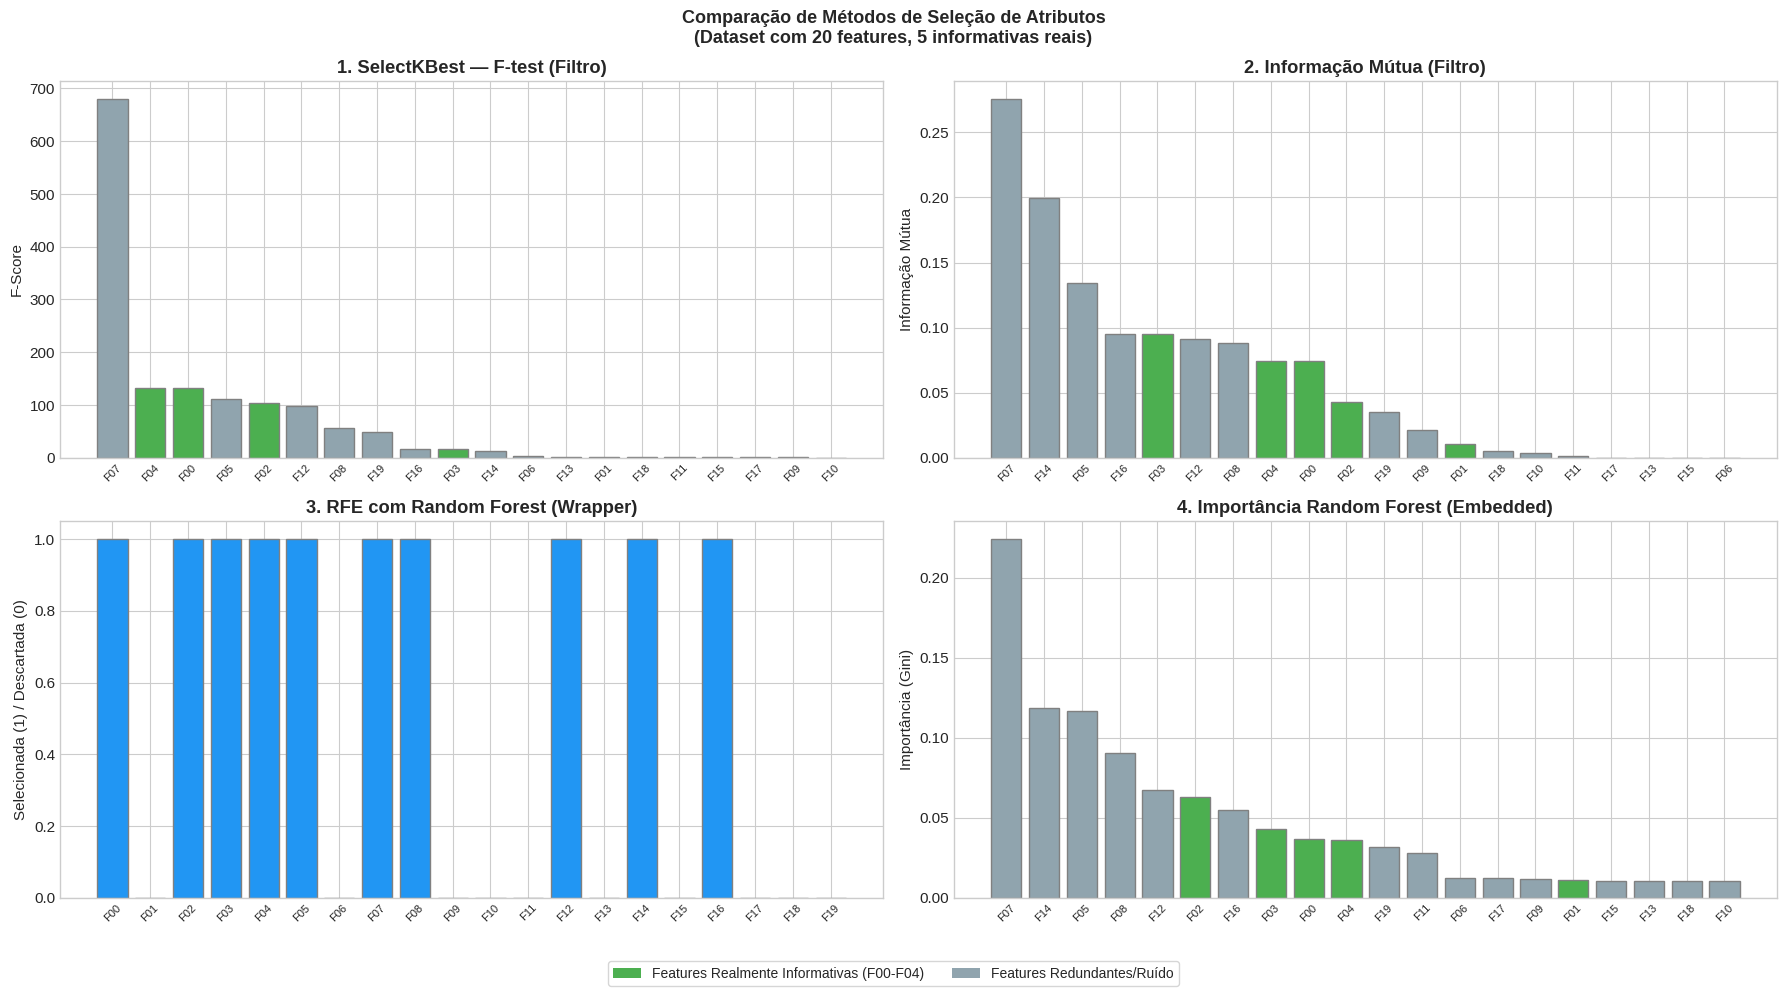

In [22]:
# ============================================================
# SELEÇÃO DE ATRIBUTOS — 4 MÉTODOS
# ============================================================

# Criar dataset com muitas features (20 total, 5 informativas)
X_high_dim, y_high_dim = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=5,       # Apenas 5 são realmente informativas
    n_redundant=5,         # 5 são combinações lineares das informativas
    n_repeated=2,          # 2 são cópias de outras
    n_classes=2,
    random_state=42
)
feature_names_hd = [f'Feature_{i:02d}' for i in range(20)]

# Normalizar
X_hd_scaled = StandardScaler().fit_transform(X_high_dim)

# --- Método 1: SelectKBest com F-test (filtro) ---
selector_f = SelectKBest(f_classif, k=10)
selector_f.fit(X_hd_scaled, y_high_dim)
scores_f = selector_f.scores_

# --- Método 2: SelectKBest com Informação Mútua (filtro) ---
selector_mi = SelectKBest(mutual_info_classif, k=10)
selector_mi.fit(X_hd_scaled, y_high_dim)
scores_mi = selector_mi.scores_

# --- Método 3: RFE com Random Forest (wrapper) ---
rfe_clf = RandomForestClassifier(n_estimators=50, random_state=42)
rfe = RFE(estimator=rfe_clf, n_features_to_select=10, step=1)
rfe.fit(X_hd_scaled, y_high_dim)
scores_rfe = rfe.ranking_  # Ranking (1 = selecionada)

# --- Método 4: Importância em Random Forest (embedded) ---
rf_imp = RandomForestClassifier(n_estimators=200, random_state=42)
rf_imp.fit(X_hd_scaled, y_high_dim)
scores_rf = rf_imp.feature_importances_

# --- Visualização comparativa ---
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Comparação de Métodos de Seleção de Atributos\n(Dataset com 20 features, 5 informativas reais)',
             fontsize=13, fontweight='bold')

feat_labels = [f'F{i:02d}' for i in range(20)]
colors_sel = ['#4CAF50' if i < 5 else '#90A4AE' for i in range(20)]  # Verde = realmente informativas

# F-test
ax1 = axes[0, 0]
sorted_idx1 = np.argsort(scores_f)[::-1]
ax1.bar(range(20), scores_f[sorted_idx1],
        color=[colors_sel[i] for i in sorted_idx1], edgecolor='gray')
ax1.set_xticks(range(20))
ax1.set_xticklabels([feat_labels[i] for i in sorted_idx1], rotation=45, fontsize=8)
ax1.set_title('1. SelectKBest — F-test (Filtro)', fontweight='bold')
ax1.set_ylabel('F-Score')

# Informação Mútua
ax2 = axes[0, 1]
sorted_idx2 = np.argsort(scores_mi)[::-1]
ax2.bar(range(20), scores_mi[sorted_idx2],
        color=[colors_sel[i] for i in sorted_idx2], edgecolor='gray')
ax2.set_xticks(range(20))
ax2.set_xticklabels([feat_labels[i] for i in sorted_idx2], rotation=45, fontsize=8)
ax2.set_title('2. Informação Mútua (Filtro)', fontweight='bold')
ax2.set_ylabel('Informação Mútua')

# RFE
ax3 = axes[1, 0]
rfe_selected = (scores_rfe == 1).astype(int)  # 1 se selecionada
bar_colors3 = ['#2196F3' if s == 1 else '#90A4AE' for s in rfe_selected]
ax3.bar(range(20), rfe_selected, color=bar_colors3, edgecolor='gray')
ax3.set_xticks(range(20))
ax3.set_xticklabels(feat_labels, rotation=45, fontsize=8)
ax3.set_title('3. RFE com Random Forest (Wrapper)', fontweight='bold')
ax3.set_ylabel('Selecionada (1) / Descartada (0)')

# Random Forest Feature Importance
ax4 = axes[1, 1]
sorted_idx4 = np.argsort(scores_rf)[::-1]
ax4.bar(range(20), scores_rf[sorted_idx4],
        color=[colors_sel[i] for i in sorted_idx4], edgecolor='gray')
ax4.set_xticks(range(20))
ax4.set_xticklabels([feat_labels[i] for i in sorted_idx4], rotation=45, fontsize=8)
ax4.set_title('4. Importância Random Forest (Embedded)', fontweight='bold')
ax4.set_ylabel('Importância (Gini)')

# Legenda global
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4CAF50', label='Features Realmente Informativas (F00-F04)'),
    Patch(facecolor='#90A4AE', label='Features Redundantes/Ruído')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10, frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## 🌐 7. Redução de Dimensionalidade — PCA <a id='pca'></a>

Aplicamos PCA ao dataset de alta dimensionalidade e analisamos a variância explicada.


PCA COMPLETO (20 features)
Componentes para 95% de variância: 12
Redução: 20 → 12 dimensões (60% das features originais)

  Comp |  Var. Explicada |  Var. Acumulada
-------------------------------------------
PC0001 |         0.2805 |         0.2805
PC0002 |         0.1367 |         0.4171
PC0003 |         0.0926 |         0.5098
PC0004 |         0.0632 |         0.5730
PC0005 |         0.0557 |         0.6287
PC0006 |         0.0545 |         0.6832
PC0007 |         0.0516 |         0.7348
PC0008 |         0.0503 |         0.7851
PC0009 |         0.0485 |         0.8336
PC0010 |         0.0471 |         0.8807


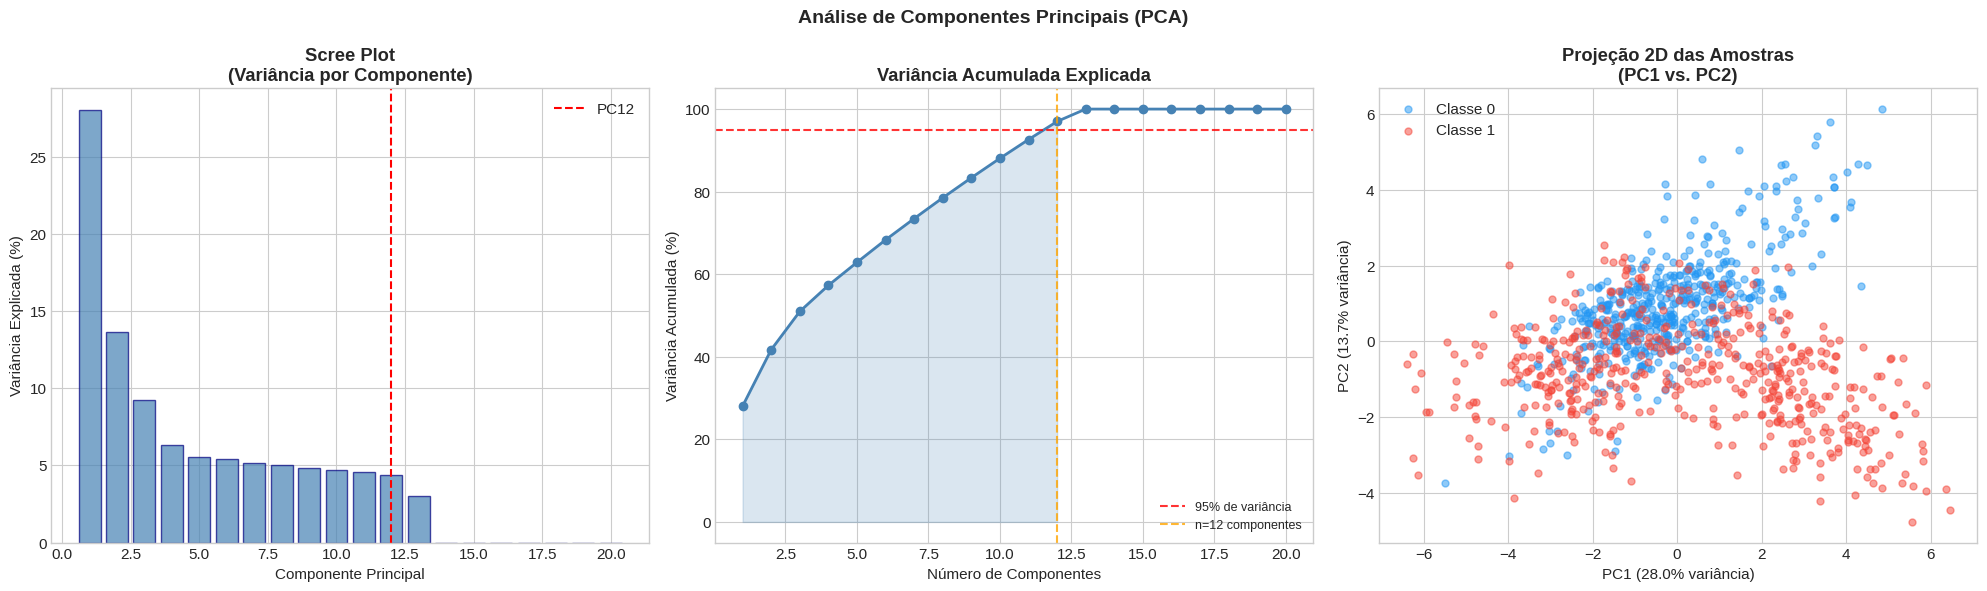

In [24]:
# ============================================================
# PCA — ANÁLISE DE COMPONENTES PRINCIPAIS
# ============================================================

# Aplicar PCA completo (todas as componentes)
pca_full = PCA(random_state=42)
X_pca_full = pca_full.fit_transform(X_hd_scaled)

# Variância explicada por componente
evr = pca_full.explained_variance_ratio_
evr_cumsum = np.cumsum(evr)

# Determinar n_components para 95% de variância
n_comp_95 = np.argmax(evr_cumsum >= 0.95) + 1

print(f'PCA COMPLETO ({X_hd_scaled.shape[1]} features)')
print('=' * 55)
print(f'Componentes para 95% de variância: {n_comp_95}')
print(f'Redução: {X_hd_scaled.shape[1]} → {n_comp_95} dimensões ({n_comp_95/X_hd_scaled.shape[1]*100:.0f}% das features originais)')
print()
print(f"{'Comp':>6} | {'Var. Explicada':>15} | {'Var. Acumulada':>15}")
print('-' * 43)
for i, (ev, cum) in enumerate(zip(evr[:10], evr_cumsum[:10])):
    marker = ' <-- 95%' if i + 1 == n_comp_95 else ''
    print(f'PC{i+1:04d} | {ev:14.4f} | {cum:14.4f}{marker}')

# --- Visualizações PCA ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Análise de Componentes Principais (PCA)', fontsize=14, fontweight='bold')

# 1. Scree plot (variância por componente)
ax1 = axes[0]
ax1.bar(range(1, len(evr) + 1), evr * 100, color='steelblue', alpha=0.7, edgecolor='navy')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Variância Explicada (%)')
ax1.set_title('Scree Plot\n(Variância por Componente)', fontweight='bold')
ax1.axvline(x=n_comp_95, color='red', linestyle='--', label=f'PC{n_comp_95}')
ax1.legend()

# 2. Variância acumulada
ax2 = axes[1]
ax2.plot(range(1, len(evr_cumsum) + 1), evr_cumsum * 100, 'o-', color='steelblue', linewidth=2)
ax2.axhline(y=95, color='red', linestyle='--', alpha=0.8, label='95% de variância')
ax2.axvline(x=n_comp_95, color='orange', linestyle='--', alpha=0.8, label=f'n={n_comp_95} componentes')
ax2.fill_between(range(1, n_comp_95 + 1), evr_cumsum[:n_comp_95] * 100, alpha=0.2, color='steelblue')
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Variância Acumulada (%)')
ax2.set_title('Variância Acumulada Explicada', fontweight='bold')
ax2.legend(fontsize=9)

# 3. Projeção 2D das classes
ax3 = axes[2]
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_hd_scaled)

colors_pca = {0: '#2196F3', 1: '#F44336'}
for class_id, color in colors_pca.items():
    mask_pca = y_high_dim == class_id
    ax3.scatter(X_pca_2d[mask_pca, 0], X_pca_2d[mask_pca, 1],
                c=color, alpha=0.5, s=25, label=f'Classe {class_id}')
ax3.set_xlabel(f'PC1 ({evr[0]*100:.1f}% variância)')
ax3.set_ylabel(f'PC2 ({evr[1]*100:.1f}% variância)')
ax3.set_title('Projeção 2D das Amostras\n(PC1 vs. PC2)', fontweight='bold')
ax3.legend()

plt.tight_layout()
plt.show()

## ⚖️ 8. Balanceamento de Classes — SMOTE <a id='smote'></a>

Comparamos estratégias de balanceamento em um dataset com desbalanceamento extremo (95/5).


DATASET DESBALANCEADO
  Classe 0: 1892 amostras (94.6%)
  Classe 1: 108 amostras (5.4%)

COMPARAÇÃO DE ESTRATÉGIAS DE BALANCEAMENTO
Estratégia                | n_treino   | Acurácia   | F1       | AUC     
----------------------------------------------------------------------
Sem balanceamento         |       1600 |     0.9750 |   0.7222 |   0.7807
Random Oversampling       |       3028 |     0.9450 |   0.6207 |   0.8813
SMOTE                     |       3028 |     0.9050 |   0.4865 |   0.8678
ADASYN                    |       3018 |     0.8600 |   0.3913 |   0.8696
Random Undersampling      |        172 |     0.7500 |   0.2754 |   0.8271


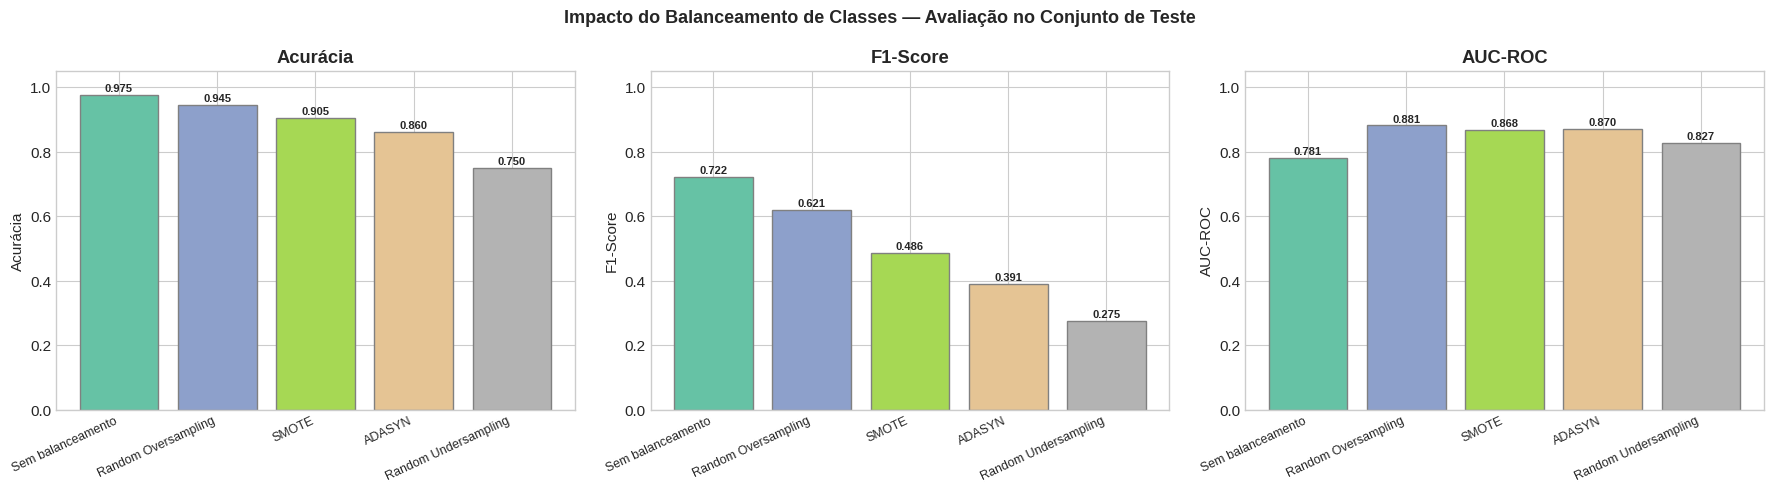


NOTA: Acurácia alta pode ser enganosa com dados desbalanceados.
Priorize F1-Score e AUC-ROC para problemas como detecção de fraude!


In [25]:
# ============================================================
# BALANCEAMENTO DE CLASSES — COMPARAÇÃO DE ESTRATÉGIAS
# ============================================================

# Criar dataset extremamente desbalanceado (95/5)
X_imb, y_imb = make_classification(
    n_samples=2000,
    n_features=10,
    n_informative=6,
    n_classes=2,
    weights=[0.95, 0.05],  # 95% classe 0, 5% classe 1
    random_state=42
)

print('DATASET DESBALANCEADO')
print('=' * 40)
unique, counts = np.unique(y_imb, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f'  Classe {cls}: {cnt} amostras ({cnt/len(y_imb)*100:.1f}%)')

# Dividir treino/teste ANTES do balanceamento (evitar data leakage!)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=42, stratify=y_imb
)

# Normalizar
sc_imb = StandardScaler()
X_tr_s = sc_imb.fit_transform(X_tr)
X_te_s = sc_imb.transform(X_te)

# Definir estratégias
balancing_strategies = {
    'Sem balanceamento':   (X_tr_s.copy(), y_tr.copy()),
}

# Aplicar cada técnica de balanceamento
for name, sampler in [
    ('Random Oversampling', RandomOverSampler(random_state=42)),
    ('SMOTE',               SMOTE(random_state=42, k_neighbors=3)),
    ('ADASYN',              ADASYN(random_state=42, n_neighbors=3)),
    ('Random Undersampling',RandomUnderSampler(random_state=42))
]:
    try:
        X_res, y_res = sampler.fit_resample(X_tr_s, y_tr)
        balancing_strategies[name] = (X_res, y_res)
    except Exception as e:
        print(f'  {name}: erro — {e}')
        balancing_strategies[name] = (X_tr_s.copy(), y_tr.copy())

# Avaliar cada estratégia
clf_bal = DecisionTreeClassifier(max_depth=5, random_state=42)

print('\nCOMPARAÇÃO DE ESTRATÉGIAS DE BALANCEAMENTO')
print('=' * 70)
print(f'{"Estratégia":25s} | {"n_treino":10s} | {"Acurácia":10s} | {"F1":8s} | {"AUC":8s}')
print('-' * 70)

balance_results = {}
for name, (X_bal, y_bal) in balancing_strategies.items():
    clf_bal.fit(X_bal, y_bal)
    y_pred_bal = clf_bal.predict(X_te_s)
    acc_b = accuracy_score(y_te, y_pred_bal)
    f1_b  = f1_score(y_te, y_pred_bal, zero_division=0)
    try:
        auc_b = roc_auc_score(y_te, clf_bal.predict_proba(X_te_s)[:, 1])
    except Exception:
        auc_b = 0.5
    balance_results[name] = {
        'n_treino': len(X_bal),
        'acc': acc_b, 'f1': f1_b, 'auc': auc_b
    }
    print(f'{name:25s} | {len(X_bal):10d} | {acc_b:10.4f} | {f1_b:8.4f} | {auc_b:8.4f}')

# Gráfico de comparação
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Impacto do Balanceamento de Classes — Avaliação no Conjunto de Teste',
             fontsize=13, fontweight='bold')

names_bal = list(balance_results.keys())
metrics_bal = ['acc', 'f1', 'auc']
metric_titles = ['Acurácia', 'F1-Score', 'AUC-ROC']
colors_bal = plt.cm.Set2(np.linspace(0, 1, len(names_bal)))

for ax, metric, title in zip(axes, metrics_bal, metric_titles):
    values = [balance_results[n][metric] for n in names_bal]
    bars = ax.bar(range(len(names_bal)), values, color=colors_bal, edgecolor='gray')
    ax.set_xticks(range(len(names_bal)))
    ax.set_xticklabels(names_bal, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel(title)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 1.05)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., val + 0.01,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()
print('\nNOTA: Acurácia alta pode ser enganosa com dados desbalanceados.')
print('Priorize F1-Score e AUC-ROC para problemas como detecção de fraude!')

## 🔗 9. Pipeline Completo de Pré-processamento <a id='pipeline'></a>

Construímos um pipeline completo com `ColumnTransformer` que trata
features numéricas e categóricas separadamente, evitando data leakage (Vazamento).


In [ ]:
# ============================================================
# PIPELINE COMPLETO COM COLUMNTRANSFORMER
# ============================================================

# Criar dataset misto (numérico + categórico)
np.random.seed(42)
n = 600

# Features numéricas (com alguns NaN)
idade      = np.random.normal(35, 12, n)
salario    = np.random.lognormal(8.5, 0.5, n)  # Log-normal (assimétrico)
experiencia = np.random.gamma(3, 2, n)           # Gamma (sempre positivo)
score      = np.random.normal(600, 100, n)
n_transacoes = np.random.poisson(15, n).astype(float)

# Introduzir NaN nas numéricas
for arr in [salario, experiencia, n_transacoes]:
    nan_idx = np.random.choice(n, size=int(0.10 * n), replace=False)
    arr[nan_idx] = np.nan

# Features categóricas (com alguns NaN)
educacoes  = np.random.choice(['Fundamental', 'Médio', 'Superior', 'Pós-Grad'], n,
                               p=[0.1, 0.35, 0.40, 0.15])
estados    = np.random.choice(['PA', 'SP', 'RJ', 'MG', 'BA', 'PR'], n)

# Introduzir NaN nas categóricas
for arr in [educacoes, estados]:
    nan_idx = np.random.choice(n, size=int(0.08 * n), replace=False)
    arr[nan_idx] = None

# Target
churn = (salario / 10000 < 1.5).astype(int)   # Proxy para churn
churn = np.where(np.isnan(churn), 0, churn) #

# Criar DataFrame
df_mixed = pd.DataFrame({
    'idade':       idade,
    'salario':     salario,
    'experiencia': experiencia,
    'score':       score,
    'n_transacoes':n_transacoes,
    'educacao':    educacoes,
    'estado':      estados,
    'churn':       churn.astype(int)
})

print('DATASET MISTO (Numérico + Categórico)')
print('=' * 55)
print(f'Dimensões: {df_mixed.shape}')
print(f'Valores ausentes:\n{df_mixed.isnull().sum()}')
print()
display(df_mixed.head(5))

# Separar features e target
numeric_features    = ['idade', 'salario', 'experiencia', 'score', 'n_transacoes']
categorical_features = ['educacao', 'estado']
X_mixed = df_mixed[numeric_features + categorical_features]
y_mixed = df_mixed['churn'].values

# Divisão treino/teste
X_tr_mix, X_te_mix, y_tr_mix, y_te_mix = train_test_split(
    X_mixed, y_mixed, test_size=0.2, random_state=42, stratify=y_mixed
)

# --- Construir o Pipeline ---
# Pipeline para features numéricas: imputa pela mediana, depois normaliza
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Pipeline para features categóricas: imputa pela moda, depois One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combinar transformadores com ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer,    numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Pipeline completo: pré-processamento + classificador
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        n_estimators=150,
        max_depth=6,
        class_weight='balanced',
        random_state=42
    ))
])

# Treinar o pipeline completo
full_pipeline.fit(X_tr_mix, y_tr_mix)

# Avaliar
y_pred_mix = full_pipeline.predict(X_te_mix)
acc_mix = accuracy_score(y_te_mix, y_pred_mix)

print('\nRESULTADOS DO PIPELINE COMPLETO')
print('=' * 55)
print(f'Acurácia no Teste: {acc_mix:.4f} ({acc_mix*100:.2f}%)')
print()
print('Relatório de Classificação:')
print(classification_report(y_te_mix, y_pred_mix,
                             target_names=['Não Churn', 'Churn'], digits=4))

# Cross-validation
cv_pipeline = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(full_pipeline, X_mixed, y_mixed, cv=cv_pipeline, scoring='f1')
print(f'Validação Cruzada (5-fold) F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

DATASET MISTO (Numérico + Categórico)
Dimensões: (600, 8)
Valores ausentes:
idade            0
salario         60
experiencia     60
score            0
n_transacoes    60
educacao         0
estado           0
churn            0
dtype: int64



,idade,salario,experiencia,score,n_transacoes,educacao,estado,churn
0,40.960570,7175.977787,5.752858,553.559574,NaN,Médio,MG,1
1,33.340828,3099.255926,4.050235,646.206089,NaN,Superior,RJ,1
2,42.772262,7591.640298,5.494506,678.339051,NaN,Pós-Grad,BA,1
3,53.276358,9680.016932,NaN,574.846111,NaN,Médio,RJ,1
4,32.190160,6043.372232,1.938812,540.248981,16.0,Médio,RJ,1



RESULTADOS DO PIPELINE COMPLETO
Acurácia no Teste: 0.9333 (93.33%)

Relatório de Classificação:
              precision    recall  f1-score   support

   Não Churn     0.7143    0.7143    0.7143        14
       Churn     0.9623    0.9623    0.9623       106

    accuracy                         0.9333       120
   macro avg     0.8383    0.8383    0.8383       120
weighted avg     0.9333    0.9333    0.9333       120

Validação Cruzada (5-fold) F1: 0.9849 ± 0.0097


## 🎓 10. Exercícios <a id='exercicios'></a>

Complete os exercícios abaixo para consolidar o aprendizado do Módulo 2.


In [ ]:
# ============================================================
# EXERCÍCIOS PRÁTICOS — TEMPLATES PARA COMPLETAR
# ============================================================

from sklearn.datasets import load_diabetes, load_breast_cancer

# ---------------------------------------------------------
# EXERCÍCIO 1: EDA e Diagnóstico em Novo Dataset
# ---------------------------------------------------------
print('EXERCÍCIO 1: Diagnóstico de Qualidade — Dataset Diabetes')
print('Objetivo: Repetir o processo de diagnóstico em outro dataset.')
print()

diabetes = load_diabetes()
df_diab = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_diab['target'] = diabetes.target

print(f'Shape: {df_diab.shape}')
print('Primeiras linhas:')
display(df_diab.head(3))

print('\n--- SUA VEZ ---')
print('TODO 1a: Mostre o número de valores ausentes por coluna')
print('TODO 1b: Calcule estatísticas descritivas')
print('TODO 1c: Crie um heatmap de correlações')
print('TODO 1d: Identifique outliers usando o método IQR')
# ... seu código aqui ...

print()
print('=' * 60)

# ---------------------------------------------------------
# EXERCÍCIO 2: Implementar SMOTE manualmente
# ---------------------------------------------------------
print('EXERCÍCIO 2: Implementar SMOTE Manualmente')
print('Objetivo: Entender a geração de amostras sintéticas.')
print()
print("""def smote_manual(X_minority, n_synthetic=100, k=5, random_state=42):
    '''
    Gera n_synthetic amostras sintéticas da classe minoritária.

    Algoritmo:
    1. Para cada instância em X_minority:
       a. Encontrar os k vizinhos mais próximos
       b. Selecionar aleatoriamente um vizinho
       c. Interpolar: x_new = x_i + lambda * (x_nn - x_i)
       d. lambda ~ Uniform(0, 1)
    '''
    from sklearn.neighbors import NearestNeighbors
    rng = np.random.RandomState(random_state)
    # TODO: Implementar a geração de amostras sintéticas
    synthetic = []
    # ... seu código aqui ...
    return np.array(synthetic)
""")

print('TODO: Implemente a função acima e teste com os dados desbalanceados.')
print()
print('=' * 60)

# ---------------------------------------------------------
# EXERCÍCIO 3: Pipeline com Seleção de Features
# ---------------------------------------------------------
print('EXERCÍCIO 3: Adicionar Seleção de Features ao Pipeline')
print('Objetivo: Estender o pipeline completo com seleção de atributos.')
print()
print("""# TODO: Modifique o full_pipeline para incluir uma etapa de
#       seleção de features entre o preprocessor e o classifier.
#
# Dica:
# from sklearn.feature_selection import SelectFromModel
#
# full_pipeline_v2 = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('selector', SelectFromModel(
#         RandomForestClassifier(n_estimators=50, random_state=42),
#         threshold='median'
#     )),
#     ('classifier', RandomForestClassifier(...))
# ])
#
# Compare o desempenho (acurácia, F1) do pipeline original
# vs. o pipeline com seleção de features usando cross-validation.
""")
print('TODO: Implemente e compare os dois pipelines!')

## 📚 Resumo e Próximos Passos

### 🎯 Principais Aprendizados deste Notebook

| Tópico | Conceito-Chave | Ferramenta Python |
|--------|---------------|-------------------|
| **Valores Ausentes** | MCAR, MAR, MNAR | `SimpleImputer`, `KNNImputer`, `IterativeImputer` |
| **Outliers** | Z-score, IQR, Isolation Forest, LOF | `IsolationForest`, `LocalOutlierFactor` |
| **Normalização** | StandardScaler, RobustScaler, MinMax | `sklearn.preprocessing` |
| **Seleção de Features** | Filtro, Wrapper, Embedded | `SelectKBest`, `RFE`, `SelectFromModel` |
| **PCA** | Variância explicada, projeção 2D | `sklearn.decomposition.PCA` |
| **Balanceamento** | SMOTE, ADASYN, Undersampling | `imblearn` |
| **Pipeline** | ColumnTransformer, evitar data leakage | `sklearn.pipeline.Pipeline` |

### ⚠️ Lições Críticas

1. **Data Leakage**: NUNCA fit o scaler/imputer no conjunto de teste. Sempre use `.fit_transform()` apenas no treino e `.transform()` no teste — o Pipeline do sklearn garante isso automaticamente.

2. **Acurácia ≠ Qualidade**: Com dados desbalanceados, use F1-Score, Precision, Recall e AUC-ROC.

3. **Outliers ≠ Lixo**: Outliers podem ser os dados mais valiosos (fraude, anomalia crítica). Sempre investigue antes de remover.

4. **Pré-processamento é iterativo**: Volte a esta etapa sempre que os resultados de modelagem forem insatisfatórios.

### 🔗 Próximo Módulo

**Módulo 3: Classificação e Árvores de Decisão** — aprofundaremos:
- Algoritmo ID3, C4.5 e CART
- Critérios de divisão: Entropia, Ganho de Informação, Gini
- Poda de árvores e overfitting
- Ensembles: Random Forest, Bagging, Boosting

### 📖 Referências

- GARCÍA et al. (2015). *Data Preprocessing in Data Mining*. Springer.
- CHAWLA et al. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *JAIR*, 16.
- LIU, TING & ZHOU (2008). Isolation Forest. *ICDM*.
- BREUNIG et al. (2000). LOF: Identifying Density-Based Local Outliers. *SIGMOD*.
- VAN BUUREN (2018). *Flexible Imputation of Missing Data*. CRC Press.
- Documentação imbalanced-learn: https://imbalanced-learn.org/

